<a href="https://colab.research.google.com/github/chiquixs/jobsheet/blob/main/data-mining/jobsheet7/RealEstate_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Real estate.csv to Real estate (9).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB
Intercept: -13044.231917160534
Slope: [ 5.44074186e+00 -2.70791490e-01 -4.75863892e-03  1.09142527e+00
  2.29

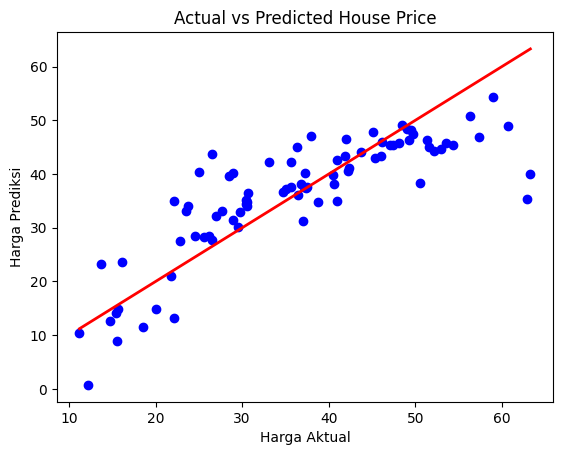

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from google.colab import files

uploaded = files.upload()

# load dataset
data = pd.read_csv("Real estate.csv")
data.head()

# data exploration
data.info()
data.describe()

# variabel independen dan dependen
x = data[['X1 transaction date', 'X2 house age',
           'X3 distance to the nearest MRT station',
           'X4 number of convenience stores',
           'X5 latitude', 'X6 longitude']]
y = data['Y house price of unit area']

# Split Data (90% train, 10% test)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_)

# Prediction
y_pred = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

# Visualization
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Actual vs Predicted House Price")
plt.show()